Moving avg:  Month
1     25.519608
2     26.638889
3     21.620370
4     25.111111
5     27.092593
6     24.268519
7     21.509259
8     24.037037
9     21.462963
10    25.453704
11    25.296296
12    27.703704
Name: Moving Average, dtype: float64


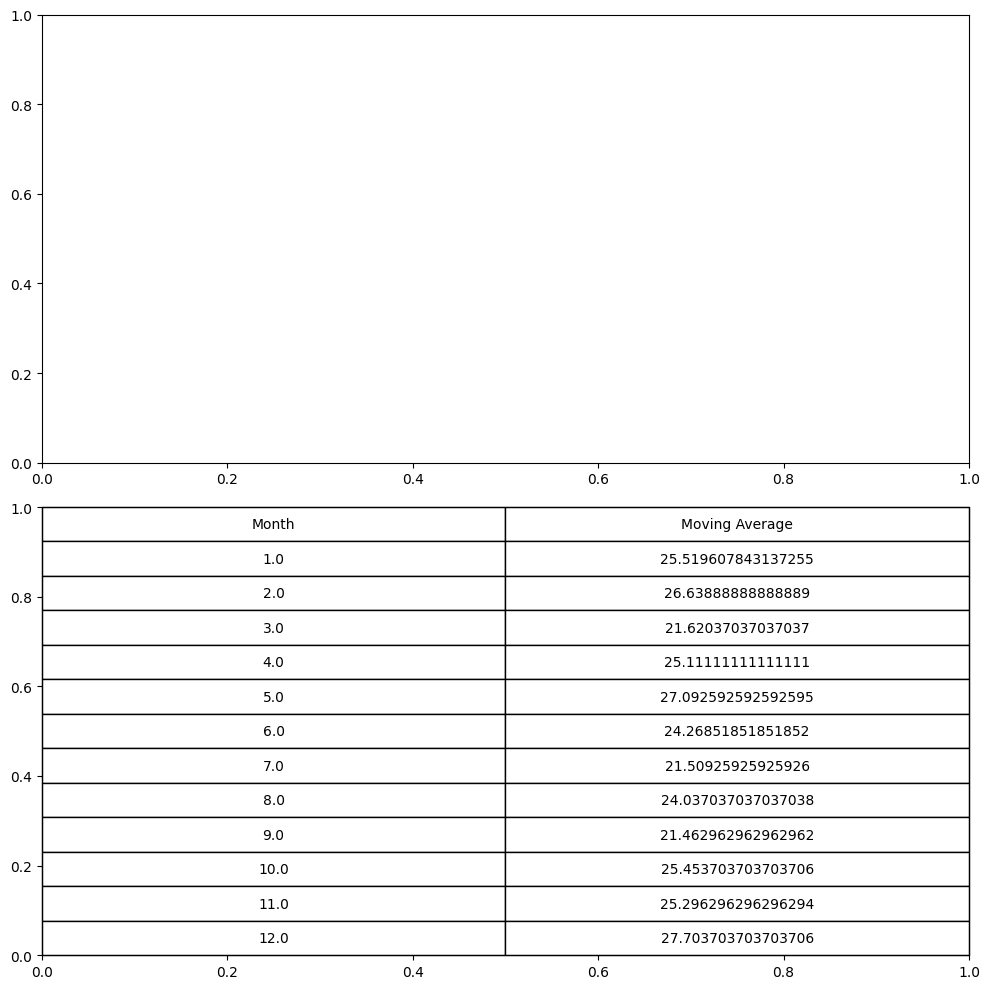

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

# データの読み込み
data = pd.read_csv('moving_average.csv')

# 2018年から2023年のデータのみを抽出
historical_data = data[(data['Year'] <= 2023)]

# 月ごとの移動平均を計算
monthly_moving_avg = historical_data.groupby('Month')['Moving Average'].mean()
print("Moving avg: ",monthly_moving_avg)

fig, ax = plt.subplots(2, 1, figsize=(10, 10))


table_data = monthly_moving_avg.reset_index().values
columns = ["Month", "Moving Average"]
table = ax[1].table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)

# グラフの表示
plt.tight_layout()
plt.show()
# 次の年の 'Year-Month' を準備
next_year = 2024
months = range(1, 13)  # 1月から12月まで


In [4]:
# 次の年のデータフレームを作成し、月ごとの移動平均を設定
future_data = pd.DataFrame({
    'Year-Month': [f"{next_year}-{str(month).zfill(2)}" for month in months],
    'Moving Average': [monthly_moving_avg[month] for month in months]  # 各月に対応する月の平均移動平均を使用
})

# 'Year-Month' を数値形式（YYYYMM形式）に変換
future_data['Year-Month'] = pd.to_datetime(future_data['Year-Month']).dt.to_period('M').astype(int)

# モデルのトレーニング
# 特徴量とターゲット変数の定義
X = historical_data[['Year-Month', 'Moving Average']].copy()
y = historical_data['Order Quantity']

# 'Year-Month' を数値形式に変換
X['Year-Month'] = pd.to_datetime(X['Year-Month']).dt.to_period('M').astype(int)

# モデルの作成とトレーニング
model = LinearRegression()
model.fit(X, y)


LinearRegression()